# Use Real Images for Processing or Somethin

This notebook runs MPI-based image processing using C++ (CUDA + MPI + OpenMP).

We dynamically pass images into the parallel program and test performance across multiple processor counts.

but yea that how it works idk

In [1]:
import subprocess
import re
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
print(os.getcwd())

c:\Users\nyoma\Downloads\mpyCUDA\Image-Convolution


In [3]:
from pathlib import Path
import os

cwd = Path(os.getcwd())
blur_dir = (cwd / "images" / "output" / "blur").resolve()
edge_dir = (cwd / "images" / "output" / "edge").resolve()

print("CWD:", cwd.resolve())
print("Blur dir:", blur_dir, "exists:", blur_dir.exists())
print("Edge dir:", edge_dir, "exists:", edge_dir.exists())

print("\nBlur files:")
print(sorted([p.name for p in blur_dir.glob("*")]) if blur_dir.exists() else "MISSING DIR")

print("\nEdge files:")
print(sorted([p.name for p in edge_dir.glob("*")]) if edge_dir.exists() else "MISSING DIR")

CWD: C:\Users\nyoma\Downloads\mpyCUDA\Image-Convolution
Blur dir: C:\Users\nyoma\Downloads\mpyCUDA\Image-Convolution\images\output\blur exists: False
Edge dir: C:\Users\nyoma\Downloads\mpyCUDA\Image-Convolution\images\output\edge exists: False

Blur files:
MISSING DIR

Edge files:
MISSING DIR


In [4]:
from pathlib import Path
Path("./images/output/blur").mkdir(parents=True, exist_ok=True)
Path("./images/output/edge").mkdir(parents=True, exist_ok=True)

In [5]:
procs = [1, 2, 4, 6, 8, 16, 24, 30, 48]
times_blur = []
times_edge = []
images = ['decade.jpg', 'kuuga.jpg', 'w_lunatrigger.png']

input_prefix = r"./images/"
output_prefix = r"./images/output"

In [6]:
for image in images:
    input_img = input_prefix + image
    for p in procs:

        cmd = [
            r"C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe",
            "-n", str(p),
            r"./scripts/parallel_image.exe",
            input_img,
            f"{output_prefix}/blur/{image[:-4]}_{p}.jpg",
            "blur"
        ]

        print("Running:", " ".join(cmd))

        result = subprocess.run(cmd, capture_output=True, text=True)
        print(result.stdout)
        print(result.stderr)

        out = subprocess.check_output(cmd).decode()

        print(out)

        t = float(re.findall(r"Time taken: ([0-9.]+)", out)[0])
        times_blur.append(t)

times_blur

Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe -n 1 ./scripts/parallel_image.exe ./images/decade.jpg ./images/output/blur/decade_1.jpg blur
Rank 0 started
Image Logic: 985x1613 channels: 3 Mode: blur with 1 ranks.
Using GUIDED scheduling for load balancing.
Time taken: 0.000112
Rank 0 finished

Please run with at least 2 ranks for Master-Worker logic.

Rank 0 started
Image Logic: 985x1613 channels: 3 Mode: blur with 1 ranks.
Using GUIDED scheduling for load balancing.
Time taken: 0.000218
Rank 0 finished

Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe -n 2 ./scripts/parallel_image.exe ./images/decade.jpg ./images/output/blur/decade_2.jpg blur
Rank 0 started
Image Logic: 985x1613 channels: 3 Mode: blur with 2 ranks.
Using GUIDED scheduling for load balancing.
Time taken: 0.154474
Rank 0 finished
Rank 1 started
Rank 1 processing rows 0 to 805
Rank 1 processing rows 806 to 1208
Rank 1 processing rows 1209 to 1410
Rank 1 processing rows 1411 to 1511
Rank 1 process

[0.000218,
 0.145184,
 0.259485,
 0.448905,
 0.541768,
 0.986182,
 1.746552,
 2.280692,
 3.935403,
 0.000117,
 0.114399,
 0.235769,
 0.617058,
 0.515926,
 1.057531,
 1.436333,
 1.902186,
 3.517719,
 0.000126,
 0.122242,
 0.313326,
 0.432883,
 0.558453,
 0.860116,
 1.489935,
 1.975821,
 3.816861]

In [7]:
for image in images:
    input_img = input_prefix + image
    for p in procs:

        cmd = [
            r"C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe",
            "-n", str(p),
            r"./scripts/parallel_image.exe",
            input_img,
            f"{output_prefix}/edge/{image[:-4]}_{p}.jpg",
            "edge"
        ]

        print("Running:", " ".join(cmd))

        result = subprocess.run(cmd, capture_output=True, text=True)
        print(result.stdout)
        print(result.stderr)

        out = subprocess.check_output(cmd).decode()

        print(out)

        t = float(re.findall(r"Time taken: ([0-9.]+)", out)[0])
        times_edge.append(t)

times_edge

Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe -n 1 ./scripts/parallel_image.exe ./images/decade.jpg ./images/output/edge/decade_1.jpg edge
Rank 0 started
Image Logic: 985x1613 channels: 3 Mode: edge with 1 ranks.
Using GUIDED scheduling for load balancing.
Time taken: 0.000084
Rank 0 finished

Please run with at least 2 ranks for Master-Worker logic.

Rank 0 started
Image Logic: 985x1613 channels: 3 Mode: edge with 1 ranks.
Using GUIDED scheduling for load balancing.
Time taken: 0.000068
Rank 0 finished

Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe -n 2 ./scripts/parallel_image.exe ./images/decade.jpg ./images/output/edge/decade_2.jpg edge
Rank 0 started
Image Logic: 985x1613 channels: 3 Mode: edge with 2 ranks.
Using GUIDED scheduling for load balancing.
Time taken: 0.135387
Rank 0 finished
Rank 1 started
Rank 1 processing rows 0 to 805
Rank 1 processing rows 806 to 1208
Rank 1 processing rows 1209 to 1410
Rank 1 processing rows 1411 to 1511
Rank 1 process

[6.8e-05,
 0.117569,
 0.18624,
 0.364217,
 0.411718,
 0.879163,
 1.609954,
 2.138445,
 3.858916,
 0.000119,
 0.142912,
 0.24629,
 0.303651,
 0.421408,
 1.255263,
 1.558886,
 2.003589,
 3.858858,
 7.9e-05,
 0.117048,
 0.244118,
 0.344487,
 0.42433,
 1.151069,
 1.607139,
 2.170595,
 3.899235]

In [10]:
import numpy as np
import matplotlib.pyplot as plt

n_images = len(images)
n_procs = len(procs)

# 3 curves (one per image) because we reshape to [image, proc]
times_blur_arr = np.array(times_blur, dtype=float).reshape(n_images, n_procs)
times_edge_arr = np.array(times_edge, dtype=float).reshape(n_images, n_procs)

speedup_blur_arr = times_blur_arr[:, [0]] / times_blur_arr
speedup_edge_arr = times_edge_arr[:, [0]] / times_edge_arr

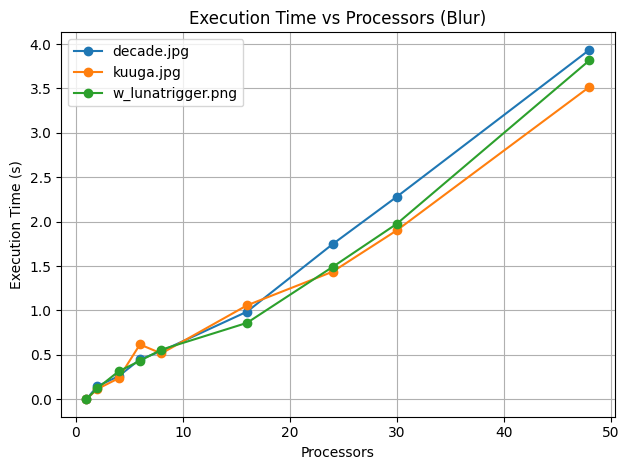

In [11]:
plt.figure()
for i, img in enumerate(images):
    plt.plot(procs, times_blur_arr[i], marker="o", label=img)
plt.xlabel("Processors")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time vs Processors (Blur)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

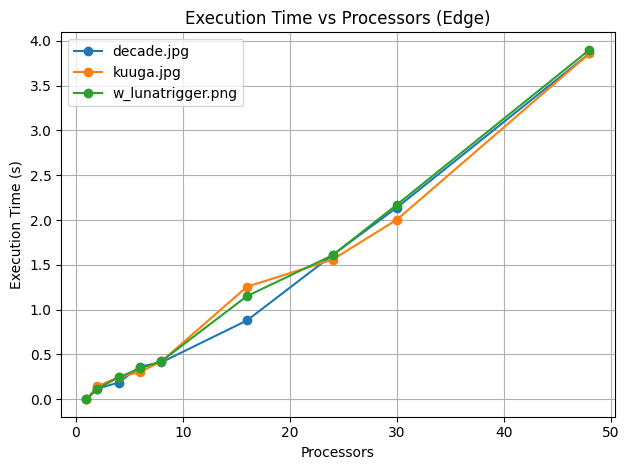

In [12]:
plt.figure()
for i, img in enumerate(images):
    plt.plot(procs, times_edge_arr[i], marker="o", label=img)
plt.xlabel("Processors")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time vs Processors (Edge)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

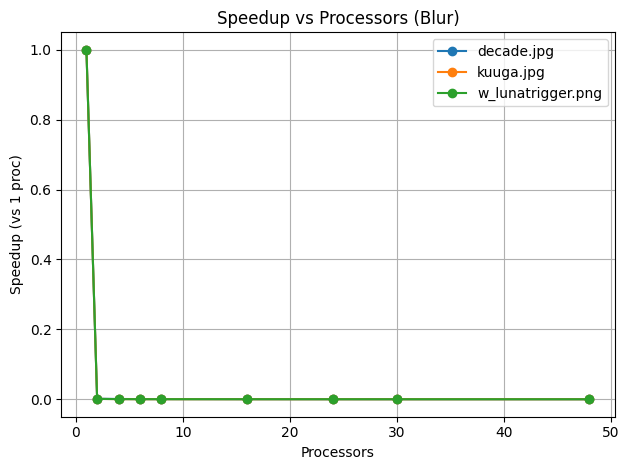

In [13]:
plt.figure()
for i, img in enumerate(images):
    plt.plot(procs, speedup_blur_arr[i], marker="o", label=img)
plt.xlabel("Processors")
plt.ylabel("Speedup (vs 1 proc)")
plt.title("Speedup vs Processors (Blur)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

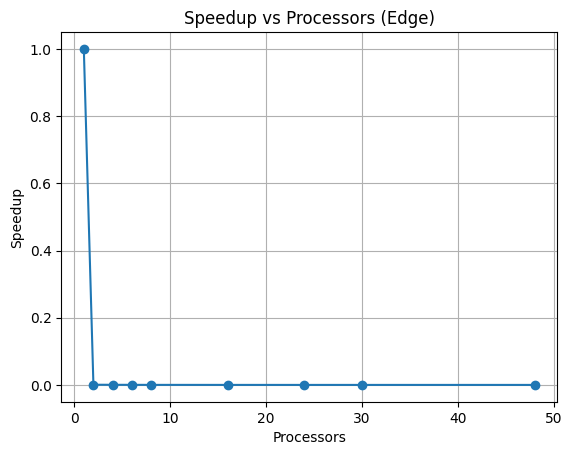

In [ ]:
plt.figure()
for i, img in enumerate(images):
    plt.plot(procs, speedup_edge_arr[i], marker="o", label=img)
plt.xlabel("Processors")
plt.ylabel("Speedup (vs 1 proc)")
plt.title("Speedup vs Processors (Edge)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()